# Single-Pulse Analysis (NPS Sessions)

Analyzes single-electrode electrical stimulation results from multi-session
`closed_loop_no_encoder_*` experiments, comparing evoked neural responses to
the visual-orientation PCA basis established in `run_visual_orientations_raster.py`.

## Notebook structure

| Cell(s) | Purpose |
|---------|---------|
| 1–3     | Install dependencies |
| 4–8     | Load visual run config, spike raster, and fit PCA on visual epoch vectors |
| 9–12    | Load spike raster from `.dat` files; plot raster |
| 13–17   | Build per-trial spike-count vectors; fit PCA; plot visual manifold |
| 18–22   | Load multi-session electrical stimulation spike bins from `.npz` files |
| 23+     | STA, linear approximation, observation-window projections |

## Neuron indexing convention

All neuron arrays in this notebook use **0-based neuron indices** that match the
pipeline directly:

```
neuron_index  ←→  sim.network.get_spike_train_list()[neuron_index]
             ←→  spike_bins_arr[:, :, neuron_index]
             ←→  spike_counts_matrix[:, neuron_index]
```

### How `.dat` raster files encode neuron identity

`closed_loop_repertoire_experiment.py` writes the raster as NEST GID ("sender"):

```python
sender = last_node_id - neuron_index   # e.g. 3858 - 0 = 3858, 3858 - 3857 = 1
```

`load_spikes_robust()` (Cell 9) inverts this exactly:

```python
neuron_idx = last_node_id - sender     # 0-based; matches spike_bins_arr column
```

`n_neurons` is read from `population_nodeids.dat` as
`last_node_id - first_node_id + 1` (always 3858 for the 0.05-scale network),
**never inferred from max observed spike index** (which would be 3857 if the
highest-indexed neuron happens not to fire in a given run).

### Visual spike rates (`visual8_spike_rates.pkl`)

These are produced by `run_visual_orientations_raster.py` using the same
0-based neuron ordering. `vis_rates[:, i]` corresponds to `neuron_index = i`.

## Data sources

| Variable | Shape | Source |
|----------|-------|--------|
| `times_all`, `neurons_all` | `(n_spikes,)` | `.dat` raster from `spike_recorder/` |
| `spike_bins_arr` | `(n_intervals, bpi, n_neurons)` | `*_spike_bins.npz` per session |
| `spike_counts_matrix` | `(n_intervals, n_neurons)` | `*_spike_counts.pkl` per session |
| `avg_vectors` | `(n_orientations, n_neurons)` | `visual8_spike_rates.pkl` |
| `pca` | sklearn PCA | fit on `avg_vectors` |


# Load visual response properties

In [2]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [4]:
# Load run config generated by run_visual_orientations_raster.py
run_data_path = "outputs/visual_orientations_8"
print ("Looking for run config in:", run_data_path)
run_config_path = os.path.join(run_data_path, "visual8_run_config.pkl")

with open(run_config_path, "rb") as f:
    run_config = pickle.load(f)

orientations_deg = run_config["orientations_deg"]
n_repeats = run_config["n_repeats"]
dt_ms = run_config["dt_ms"]
on_duration_ms = run_config["on_duration_ms"]
off_duration_ms = run_config["off_duration_ms"]
input_duration_ms = run_config["input_duration_ms"]
epoch_info = run_config["epoch_info"]
sample_info = run_config["sample_info"]
presim_ms = run_config["presim_ms"]
data_path = run_config["data_path"]

print("Loaded run config:", run_config_path)
print("orientations:", orientations_deg)
print("repeats:", n_repeats)
print("input_duration_ms:", input_duration_ms)

Looking for run config in: outputs/visual_orientations_8


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/visual_orientations_8/visual8_run_config.pkl'

In [4]:
# Analysis notebook: no simulation is run here.
# First run: python run_visual_orientations_raster.py
print("Data path:", data_path)
print("Presim (ms):", presim_ms)

print("Loaded metadata for analysis.")
print("Expected samples (angles x repeats):", len(orientations_deg) * n_repeats)
print("Number of trials (orientations x repeats):", len(sample_info))

Data path: /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/visual_orientations_8
Presim (ms): 1000
Loaded metadata for analysis.
Expected samples (angles x repeats): 80
Number of trials (orientations x repeats): 80


In [62]:
def load_spikes_robust(path, name_prefix, begin_ms, end_ms):
    spike_files = sorted(glob.glob(os.path.join(path, f"{name_prefix}-*.dat")))
    if len(spike_files) == 0:
        raise FileNotFoundError(f"No files found for prefix '{name_prefix}' in {path}")

    node_ids = np.loadtxt(os.path.join(path, "population_nodeids.dat"), dtype=int)
    if node_ids.ndim == 1:
        node_ids = node_ids[None, :]
    first_node_id = node_ids[0, 0]
    last_node_id = node_ids[-1, -1]
    # Node IDs are 1-based and contiguous, so total neurons = last_node_id - first_node_id + 1
    n_neurons_total = last_node_id - first_node_id + 1
    print (n_neurons_total, " neuron IDs total")
    all_times = []
    all_neurons = []

    for file_path in spike_files:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                parts = stripped.split()
                if len(parts) < 2:
                    continue
                try:
                    sender = int(float(parts[0]))
                    time_ms = float(parts[1])
                except ValueError as e:
                    # print(f"Warning: could not parse line in {file_path}: '{line.strip()}'. Error: {e}")
                    continue

                if begin_ms <= time_ms <= end_ms:
                    neuron_idx = sender # indexes are same as the spike files; largest index is deepest and smallest idx is most superficial
                    all_times.append(time_ms)
                    all_neurons.append(neuron_idx)
    all_neurons = np.array(all_neurons)
    print (np.unique(all_neurons).shape[0], " neurons spiked")
    non_firing_neurons = set(range(first_node_id, last_node_id + 1)) - set(all_neurons)
    # Spike times are 0-indexed, but node IDs are 1-indexed, so neuron index = node_id - 1
    return np.asarray(all_times), np.asarray(all_neurons), n_neurons_total, spike_files, non_firing_neurons
print ("Defined robust spike loading function.")    

# Plot window in stimulus-aligned time (ms)
raster_begin_ms = 0
raster_end_ms = input_duration_ms

# Convert to absolute simulation-time window and guard against negative start
begin_abs_ms = max(0.0, raster_begin_ms + presim_ms)
end_abs_ms = raster_end_ms + presim_ms

print (begin_abs_ms, end_abs_ms, "ms absolute time window for spike loading")

# Spike recorder files are now in a spike_recorder/ subdirectory
sd_dir = os.path.join(data_path, "spike_recorder")

times_all, neurons_all, n_neurons_vis, spike_files, nonfiring_neuron_idxs = load_spikes_robust(
    sd_dir,
    "spike_recorder",
    begin_abs_ms,
    end_abs_ms,
)

'''
Total silent: 229

L23e  (IDs    1-1034, n=1034): 188 silent (18.2%)
L23i  (IDs 1035-1326, n= 292):   2 silent (0.7%)
L4e   (IDs 1327-2422, n=1096):   0 silent (0.0%)
L4i   (IDs 2423-2696, n= 274):   0 silent (0.0%)
L5e   (IDs 2697-2938, n= 242):   0 silent (0.0%)
L5i   (IDs 2939-2991, n=  53):   0 silent (0.0%)
L6e   (IDs 2992-3711, n= 720):  39 silent (5.4%)
L6i   (IDs 3712-3858, n= 147):   0 silent (0.0%)
'''
# Shift to stimulus-aligned axis where 0 ms is visual stimulus onset
times_all = times_all - presim_ms

print(f"Loaded {len(times_all)} spikes from {len(spike_files)} files.")
print (f"{len(nonfiring_neuron_idxs)} neurons did not fire in the window, including neuron indices: {sorted(nonfiring_neuron_idxs)}")
if len(times_all) > 0:
    print(f"Spike time range (stim-aligned): {times_all.min():.1f} to {times_all.max():.1f} ms")


Defined robust spike loading function.
1000 12200.0 ms absolute time window for spike loading
3858  neuron IDs total
3629  neurons spiked
Loaded 92618 spikes from 32 files.
229 neurons did not fire in the window, including neuron indices: [1, 30, 32, 33, 35, 37, 47, 49, 57, 58, 63, 64, 66, 73, 74, 94, 95, 100, 105, 108, 109, 110, 115, 117, 125, 128, 137, 146, 150, 154, 176, 185, 195, 196, 206, 216, 226, 228, 230, 234, 238, 242, 248, 254, 270, 276, 279, 285, 286, 287, 296, 297, 298, 309, 310, 315, 318, 325, 329, 337, 340, 342, 348, 354, 355, 357, 360, 365, 368, 370, 373, 376, 377, 378, 385, 391, 398, 402, 407, 411, 416, 429, 448, 449, 455, 467, 475, 481, 492, 494, 500, 535, 544, 545, 547, 550, 580, 581, 582, 586, 587, 594, 604, 605, 607, 609, 617, 621, 625, 632, 644, 652, 661, 665, 667, 679, 685, 686, 691, 697, 699, 724, 726, 729, 731, 732, 750, 751, 752, 753, 755, 760, 765, 767, 769, 772, 775, 787, 797, 801, 803, 816, 822, 827, 828, 838, 840, 842, 848, 852, 879, 880, 883, 884, 886, 887

In [38]:
import plotly.graph_objects as go

if len(times_all) == 0:
    print("No spikes found in selected range.")
else:
    ymin, ymax = np.min(neurons_all), np.max(neurons_all)

    fig = go.Figure()

    # Spike raster
    fig.add_trace(go.Scattergl(
        x=times_all, y=neurons_all,
        mode="markers",
        marker=dict(size=1.5, color="black", opacity=0.7),
        name="spikes",
    ))

    # Mark pre-stim period
    if raster_begin_ms < 0:
        fig.add_vrect(
            x0=raster_begin_ms, x1=0,
            fillcolor="royalblue", opacity=0.08, line_width=0,
            annotation_text="pre-stim", annotation_position="top",
        )

    # Mark stimulus-on orientation epochs
    for start_ms, end_ms, label in epoch_info:
        fig.add_vrect(
            x0=start_ms, x1=end_ms,
            fillcolor="orange", opacity=0.12, line_width=0,
            annotation_text=label, annotation_position="top",
            annotation_font_size=9,
        )

    fig.update_layout(
        width=1200, height=500,
        xaxis_title="Time (ms, stimulus-aligned)",
        yaxis_title="Neuron index",
        title="Population raster with pre-stim and orientation epochs",
        xaxis=dict(range=[raster_begin_ms, raster_end_ms]),
        yaxis=dict(range=[ymin, ymax + 20]),
        dragmode="zoom",
    )
    fig.show()

In [72]:
if len(times_all) == 0:
    print("No spikes available.")
else:
    # MODE options:
    #   "point_window"   — each non-overlapping window is a distinct point (5ms → 14× more points than 70ms)
    #   "sliding_window" — all windows averaged → 1 vector per trial
    #   "firstk"         — just the first trial_portion ms after stimulus onset → 1 vector per trial
    MODE               = "firstk"
    FIRST_ONLY_DELAY_MS = 0.0   # ms offset from stimulus onset before sampling (firstk only)
    EPOCH_MS           = 70.0    # total epoch length (used by point_window and sliding_window)

    n_neurons     = n_neurons_vis
    unique_angles = sorted(np.unique([s[2] for s in sample_info]))
    cmap          = plt.cm.get_cmap("tab10", len(unique_angles))

    def _epoch_vectors(start_ms, trial_portion):
        n_wins = max(1, int(EPOCH_MS / trial_portion))

        if MODE == "firstk":
            ws     = start_ms + FIRST_ONLY_DELAY_MS
            mask   = (times_all >= ws) & (times_all < ws + trial_portion)
            counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)[:n_neurons]
            return [counts]

        win_vecs = []
        for w in range(n_wins):
            ws   = start_ms + w * trial_portion
            mask = (times_all >= ws) & (times_all < ws + trial_portion)
            counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)[:n_neurons]
            win_vecs.append(counts)

        if MODE == "sliding_window":
            return [np.mean(win_vecs, axis=0)]
        else:  # point_window
            return win_vecs

    # Return a dataset of angles, and spike counts. The shape of the spike count data will depend on the MODE:
    # - "firstk":         (n_trials, n_neurons)
    # - "sliding_window": (n_trials, n_neurons)
    # - "point_window":   (n_trials * n_wins, n_neurons)
    trial_portion = EPOCH_MS  # use full epoch for firstk / sliding_window; change as needed

    sample_vectors, sample_angles = [], []
    for start_ms, end_ms, angle_deg, repeat_idx in sample_info:
        for vec in _epoch_vectors(start_ms, trial_portion):
            sample_vectors.append(vec)
            sample_angles.append(angle_deg)

    sample_vectors = np.asarray(sample_vectors)   # (n_samples, n_neurons)
    sample_angles  = np.asarray(sample_angles)    # (n_samples,)

    # Per-angle mean spike count vectors
    avg_vectors = np.array([sample_vectors[sample_angles == a].mean(0) for a in unique_angles])
    # avg_vectors shape: (n_unique_angles, n_neurons)

    print(f"sample_vectors shape : {sample_vectors.shape}")
    print(f"sample_angles  shape : {sample_angles.shape}")
    print(f"avg_vectors    shape : {avg_vectors.shape}")
    print(f"unique angles        : {[int(a) for a in unique_angles]}")


sample_vectors shape : (80, 3858)
sample_angles  shape : (80,)
avg_vectors    shape : (8, 3858)
unique angles        : [0, 45, 90, 135, 180, 225, 270, 315]


/tmp/ipykernel_4173789/3258702924.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = plt.cm.get_cmap("tab10", len(unique_angles))


In [73]:
# Learn visual PROJECTION matrix.

# make this a function that I can call at other places
pca = PCA(n_components=2)
pca.fit(avg_vectors)
proj, _ = np.linalg.qr(np.array([avg_vectors.mean(0), pca.components_[0], pca.components_[1]]).T)
avg_proj = avg_vectors.dot(proj)


In [74]:
avg_vectors.shape

(8, 3858)

In [75]:
# plotting code
import plotly.graph_objects as go

# Orientation colormap
ori_cmap   = plt.get_cmap("hsv")
ori_colors = {a: ori_cmap(i / len(orientations_deg)) for i, a in enumerate(orientations_deg)}

def rgba_from_mpl(c, alpha=1.0):
    """Convert a matplotlib color tuple (r,g,b,a) to a plotly rgba string."""
    r, g, b, _ = c
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"

traces = []
for i, angle in enumerate(orientations_deg):
    color = rgba_from_mpl(ori_colors[angle])
    traces.append(go.Scatter3d(
        x=[avg_proj[i, 0]], y=[avg_proj[i, 1]], z=[avg_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"{angle}°",
    ))

# Origin marker
traces.append(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode="markers",
    marker=dict(size=10, color="black", symbol="x"),
    name="Zero",
))

fig = go.Figure(data=traces)
fig.update_layout(
    title="PCA of Average Visual Response Vectors",
    scene=dict(
        xaxis_title="Proj 1",
        yaxis_title="Proj 2",
        zaxis_title="Proj 3",
    ),
    legend=dict(title="Orientation"),
    width=800, height=650,
)
fig.show()


Text(0, 0.5, 'Spike count over 70ms after stimulus onset')

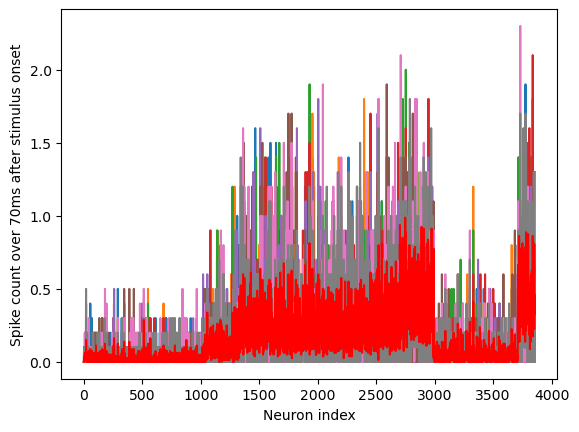

In [70]:
plt.plot(avg_vectors.T)
plt.plot(pca.mean_, 'r')
plt.xlabel('Neuron index')
plt.ylabel('Spike count over 70ms after stimulus onset')

# Electrical response property

In [78]:
import os
import pickle
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# ── Paths ──────────────────────────────────────────────────────────────────
# 32 channel
# DATA_DIR = "/Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/no_encoder_1sinterval_sessions/"
# N_STIM_CHANNELS = 32
# prefix = 'closed_loop_no_encoder_1sinterval_session_'

# 128 channel
DATA_DIR = "outputs/data_system_sim_0.05scale/128_stimchannel_hv_space_1sinterval"
assert os.path.exists(DATA_DIR), f"Data directory not found: {DATA_DIR}"
N_STIM_CHANNELS = 128
prefix = '128_stimchannel_1sinterval'

VIZ_DIR = os.path.join(DATA_DIR, "viz")
os.makedirs(VIZ_DIR, exist_ok=True)



# Count sessions
session_dirs = sorted([d for d in os.listdir(DATA_DIR) 
                       if d.startswith(prefix) 
                       and os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Loading {len(session_dirs)} sessions...")
for d in session_dirs:
    print(f"  - {d}")


Loading 8 sessions...
  - 128_stimchannel_1sinterval_no_encoder_run1_session_000
  - 128_stimchannel_1sinterval_no_encoder_run1_session_001
  - 128_stimchannel_1sinterval_no_encoder_run1_session_002
  - 128_stimchannel_1sinterval_no_encoder_run1_session_003
  - 128_stimchannel_1sinterval_no_encoder_run1_session_004
  - 128_stimchannel_1sinterval_no_encoder_run1_session_005
  - 128_stimchannel_1sinterval_no_encoder_run1_session_006
  - 128_stimchannel_1sinterval_no_encoder_run1_session_007


In [22]:
# ── Neuron & Electrode Location Map ────────────────────────────────────────
# Read volume bounds from the first session's config (not hardcoded).
import plotly.graph_objects as go

_first_session_dir = session_dirs[0]
_first_session_path = os.path.join(DATA_DIR, _first_session_dir)
_first_config_path = next(
    f for f in os.listdir(_first_session_path)
    if f.endswith("_config.json") and f.startswith(prefix.split("_session_")[0] if "_session_" in prefix else prefix)
)
with open(os.path.join(_first_session_path, _first_config_path)) as _f:
    _bounds = json.load(_f)["electrode_volume_bounds_um"]
_v_min, _v_max = _bounds["v_min"], _bounds["v_max"]
_h_min, _h_max = _bounds["h_min"], _bounds["h_max"]

# Reproduce electrode grid from config bounds (same logic as system.make_electrode_grid)
_n_ch = N_STIM_CHANNELS
_n_h = int(np.sqrt(_n_ch))
while _n_ch % _n_h != 0:
    _n_h -= 1
_n_v = _n_ch // _n_h
_h_vals = np.linspace(_h_min, _h_max, _n_h)
_v_vals = np.linspace(_v_min, _v_max, _n_v)
_hh, _vv = np.meshgrid(_h_vals, _v_vals)
electrode_h = _hh.ravel()
electrode_v = _vv.ravel()

# Reproduce neuron locations from network params
from corcol_params.network_params import net_dict as _net_dict
_pop_names = _net_dict["populations"]
_pop_depths = _net_dict["pop_depth_ranges_um"]
_horiz = _net_dict["pop_horiz_ranges_um"]
_full_n = _net_dict["full_num_neurons"]
_nscale = _net_dict["N_scaling"]
_num_neurons_per_pop = np.round(_full_n * _nscale).astype(int)

# Use a fixed seed so layout is reproducible
_rng = np.random.default_rng(seed=0)
neuron_h_all, neuron_v_all, neuron_pop_all = [], [], []
for _i, _pname in enumerate(_pop_names):
    _nn = _num_neurons_per_pop[_i]
    _locs = _rng.random((_nn, 2))
    _locs[:, 0] = _locs[:, 0] * (_horiz[1] - _horiz[0]) + _horiz[0]
    _d = _pop_depths[_i]
    _locs[:, 1] = _locs[:, 1] * (_d[1] - _d[0]) + _d[0]
    neuron_h_all.append(_locs[:, 0])
    neuron_v_all.append(_locs[:, 1])
    neuron_pop_all.append([_pname] * _nn)

neuron_h_all = np.concatenate(neuron_h_all)
neuron_v_all = np.concatenate(neuron_v_all)
neuron_pop_all = sum(neuron_pop_all, [])

# ── Plotly figure ──────────────────────────────────────────────────────────
_pop_colors = {
    "L23E": "#1f77b4", "L23I": "#aec7e8",
    "L4E":  "#ff7f0e", "L4I":  "#ffbb78",
    "L5E":  "#2ca02c", "L5I":  "#98df8a",
    "L6E":  "#d62728", "L6I":  "#ff9896",
}

fig = go.Figure()

# Neurons by population
for _pname in _net_dict["populations"]:
    _mask = [p == _pname for p in neuron_pop_all]
    fig.add_trace(go.Scatter(
        x=neuron_h_all[_mask],
        y=neuron_v_all[_mask],
        mode="markers",
        marker=dict(size=2, color=_pop_colors[_pname], opacity=0.4),
        name=_pname,
        legendgroup="neurons",
        legendgrouptitle_text="Neurons",
    ))

# Electrodes (annotated with channel index)
fig.add_trace(go.Scatter(
    x=electrode_h,
    y=electrode_v,
    mode="markers+text",
    marker=dict(size=10, color="black", symbol="x", line=dict(width=1)),
    text=[str(i) for i in range(N_STIM_CHANNELS)],
    textposition="middle right",
    textfont=dict(size=8, color="black"),
    name=f"Electrodes ({N_STIM_CHANNELS}ch)",
    legendgroup="electrodes",
))

fig.update_layout(
    title=f"Neuron & Electrode Locations ({N_STIM_CHANNELS} channels)",
    xaxis_title="Horizontal (um)",
    yaxis_title="Depth (um)",
    yaxis=dict(autorange="reversed"),  # depth increases downward
    width=700,
    height=800,
    template="plotly_white",
    legend=dict(groupclick="togglegroup"),
)
fig.show()

In [81]:
# ── Aggregate multi-session spike data ────────────────────────────────────
import pandas as pd


# Collect data from all sessions
all_spike_bins_list = []
all_spike_counts_list = []
all_histories = []
sessions_loaded = []

# Rich indexing structures for variable trial counts
session_map = {}            # (session_id, trial_idx, repertoire_idx) -> global_interval_idx
global_interval_idx = 0
global_trial_idx = 0
trial_structure_per_session = {}
condition_interval_map = defaultdict(list)   # (ch, amp_uA) -> [global_interval_idx, ...]
condition_trial_map = defaultdict(set)       # (ch, amp_uA) -> {(session_id, trial_idx), ...}
no_stim_interval_indices = []
no_stim_trial_keys = set()

session_dirs = sorted([d for d in os.listdir(DATA_DIR)
                       if d.startswith(prefix)
                       and os.path.isdir(os.path.join(DATA_DIR, d))])

for session_dir in session_dirs:
    session_path = os.path.join(DATA_DIR, session_dir)
    # Extract session number from directory name (e.g., "closed_loop_no_encoder_1sinterval_session_000" -> 0)
    session_id = int(session_dir.split("_")[-1])
    print ("Session: ", session_id)
    # Load config (find by suffix, no hardcoded prefix)
    _cfg_files = [f for f in os.listdir(session_path) if f.endswith("_config.json")]
    _pkl_files = [f for f in os.listdir(session_path) if f.endswith("_config.pkl")]
    if _cfg_files:
        with open(os.path.join(session_path, _cfg_files[0])) as f:
            session_config = json.load(f)
    elif _pkl_files:
        with open(os.path.join(session_path, _pkl_files[0]), "rb") as f:
            session_config = pickle.load(f)
    else:
        raise FileNotFoundError(f"No config file found in {session_path}")

    # Load history
    # Load history (find by suffix)
    _hist_file = next(f for f in os.listdir(session_path) if f.endswith("_history.pkl"))
    with open(os.path.join(session_path, _hist_file), "rb") as f:
        session_history = pickle.load(f)
    
    # Load spike data (find by suffix)
    _bins_file = next(f for f in os.listdir(session_path) if f.endswith("_spike_bins.npz"))
    d = np.load(os.path.join(session_path, _bins_file))
    bin_ms = float(d["bin_ms"])
    session_spike_bins = d["spike_bins"].astype(np.float32)  # (n_intervals, bpi, n_neurons)
    print(session_spike_bins.shape)
    _counts_file = next(f for f in os.listdir(session_path) if f.endswith("_spike_counts.pkl"))
    with open(os.path.join(session_path, _counts_file), "rb") as f:
        session_spike_counts = pickle.load(f)  # (n_intervals, n_neurons)

    # Track metadata
    nest_seed = session_config.get("nest_seed", None)
    sessions_loaded.append((session_id, nest_seed))

    n_intervals_session = session_spike_bins.shape[0]
    n_repertoire_session = int(session_config.get("n_repertoire", N_STIM_CHANNELS + 1))
    n_complete_trials = n_intervals_session // n_repertoire_session
    n_complete_intervals = n_complete_trials * n_repertoire_session
    n_dropped = n_intervals_session - n_complete_intervals

    if n_dropped > 0:
        print(f"Session {session_id:03d}: dropping {n_dropped} incomplete intervals")

    # Keep complete trials only, per session (avoids cross-session assumptions).
    session_spike_bins = session_spike_bins[:n_complete_intervals]
    session_spike_counts = session_spike_counts[:n_complete_intervals]
    session_history = session_history[:n_complete_intervals]

    trial_structure_per_session[session_id] = {
        "n_intervals_raw": n_intervals_session,
        "n_repertoire": n_repertoire_session,
        "n_complete_trials": n_complete_trials,
        "n_complete_intervals": n_complete_intervals,
        "n_dropped_intervals": n_dropped,
    }

    # Session-local trial indices map to a contiguous global trial index range.
    session_trial_start = global_trial_idx

    for local_interval_idx, hist_entry in enumerate(session_history):
        trial_idx = local_interval_idx // n_repertoire_session
        repertoire_idx = local_interval_idx % n_repertoire_session

        # Copy before annotation to avoid mutating data loaded from disk.
        hist_entry = dict(hist_entry)
        hist_entry["session_id"] = session_id
        hist_entry["trial_idx_in_session"] = trial_idx
        hist_entry["repertoire_idx_in_trial"] = repertoire_idx
        hist_entry["global_interval_idx"] = global_interval_idx
        hist_entry["global_trial_idx"] = session_trial_start + trial_idx

        session_map[(session_id, trial_idx, repertoire_idx)] = global_interval_idx

        pat = hist_entry.get("delivered_pattern")
        if pat is not None and len(pat.get("channels", [])) > 0:
            ch = int(pat["channels"][0])
            amp = float(pat["amplitudes_uA"][0])
            key = (ch, amp)
            condition_interval_map[key].append(global_interval_idx)
            condition_trial_map[key].add((session_id, trial_idx))
        else:
            no_stim_interval_indices.append(global_interval_idx)
            no_stim_trial_keys.add((session_id, trial_idx))

        all_histories.append(hist_entry)
        global_interval_idx += 1

    global_trial_idx += n_complete_trials

    all_spike_bins_list.append(session_spike_bins)
    all_spike_counts_list.append(session_spike_counts)

if len(all_spike_bins_list) == 0:
    raise RuntimeError(f"No sessions found in DATA_DIR: {DATA_DIR}")

# Concatenate all spike data along interval axis
spike_bins_arr = np.concatenate(all_spike_bins_list, axis=0)  # (total_intervals, bpi, n_neurons)
spike_counts_matrix = np.concatenate(all_spike_counts_list, axis=0)  # (total_intervals, n_neurons)

# Get dimensions after per-session complete-trial filtering
n_intervals, bpi, n_neurons_raw = spike_bins_arr.shape
n_sessions = len(sessions_loaded)
total_trials = sum(v["n_complete_trials"] for v in trial_structure_per_session.values())

trials_per_session_values = [v["n_complete_trials"] for v in trial_structure_per_session.values()]
n_repertoire_values = [v["n_repertoire"] for v in trial_structure_per_session.values()]
trials_per_session = trials_per_session_values[0] if len(set(trials_per_session_values)) == 1 else None
n_repertoire = n_repertoire_values[0] if len(set(n_repertoire_values)) == 1 else None

# Config aggregation: preserve per-session structure
config = {
    "n_sessions": n_sessions,
    "sessions_loaded": sessions_loaded,
    "total_intervals": n_intervals,
    "total_trials": total_trials,
    "trials_per_session": trials_per_session,
    "trials_per_session_by_session": {sid: info["n_complete_trials"] for sid, info in trial_structure_per_session.items()},
    "n_repertoire": n_repertoire,
    "n_repertoire_by_session": {sid: info["n_repertoire"] for sid, info in trial_structure_per_session.items()},
    "bin_ms": bin_ms,
}

# History is the concatenated and annotated list
history = all_histories

# Condition-level counts (supports non-uniform trial counts by condition).
condition_interval_counts = {k: len(v) for k, v in condition_interval_map.items()}
condition_trial_counts = {k: len(v) for k, v in condition_trial_map.items()}

print(f"\n=== MULTI-SESSION AGGREGATION SUMMARY ===")
print(f"Sessions loaded: {n_sessions}")
print(f"  Session IDs: {[s[0] for s in sessions_loaded]}")
print(f"Total intervals (complete only): {n_intervals}")
if trials_per_session is None:
    print(f"Trials per session vary: min={min(trials_per_session_values)} max={max(trials_per_session_values)}")
else:
    print(f"Trials per session: {trials_per_session}")
print(f"Total trials: {total_trials}")
if n_repertoire is None:
    print(f"Repertoire size varies by session: {sorted(set(n_repertoire_values))}")
else:
    print(f"Repertoire size (n_repertoire): {n_repertoire}")
print(f"Bin resolution: {bin_ms} ms")

print(f"\nSpike data shapes:")
print(f"  spike_bins_arr: {spike_bins_arr.shape}  (total_intervals × bins_per_interval × neurons)")
print(f"  spike_counts_matrix: {spike_counts_matrix.shape}  (total_intervals × neurons)")

if len(condition_trial_counts) > 0:
    trial_count_values = list(condition_trial_counts.values())
    print(f"\nCondition trial counts (channel × amplitude):")
    print(f"  conditions with stim: {len(condition_trial_counts)}")
    print(f"  min/median/max trials per condition: {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")



Session:  0
(3076, 200, 3858)
Session:  1
(3076, 200, 3858)
Session:  2
(3076, 200, 3858)
Session:  3
(3076, 200, 3858)
Session:  4
(3076, 200, 3858)
Session:  5
(3076, 200, 3858)
Session:  6
(3076, 200, 3858)
Session:  7
(3076, 200, 3858)

=== MULTI-SESSION AGGREGATION SUMMARY ===
Sessions loaded: 8
  Session IDs: [0, 1, 2, 3, 4, 5, 6, 7]
Total intervals (complete only): 24608
Trials per session: 4
Total trials: 32
Repertoire size (n_repertoire): 769
Bin resolution: 5.0 ms

Spike data shapes:
  spike_bins_arr: (24608, 200, 3858)  (total_intervals × bins_per_interval × neurons)
  spike_counts_matrix: (24608, 3858)  (total_intervals × neurons)

Condition trial counts (channel × amplitude):
  conditions with stim: 768
  min/median/max trials per condition: 32 / 32 / 32


In [83]:
import pandas as pd

trials_df = pd.DataFrame(history)
print(f"\nHistory DataFrame shape: {trials_df.shape}")
print(f"History columns: {trials_df.columns.tolist()}")
coverage = (trials_df.groupby("session_id").aggregate({"trial_idx_in_session": "max", "repertoire_idx_in_trial": "max"}))
coverage["trial_idx_in_session"] += 1  # Convert max index to count
coverage["repertoire_idx_in_trial"] += 1   
coverage


History DataFrame shape: (24608, 11)
History columns: ['interval_index', 'interval_start_ms', 'interval_end_ms', 'n_new_spikes', 'actual_l2', 'delivered_pattern', 'session_id', 'trial_idx_in_session', 'repertoire_idx_in_trial', 'global_interval_idx', 'global_trial_idx']


,trial_idx_in_session,repertoire_idx_in_trial
session_id,,
0,4,769
1,4,769
2,4,769
3,4,769
4,4,769
5,4,769
6,4,769
7,4,769


In [53]:
# ── Stim-triggered average (STA) per stimulation pattern: neuron x time ────────
# Pattern = (electrode, current_uA).

STA_DPI = 100
WINDOW_BIN_START, WINDOW_BIN_END = 0, 14  # 50 ms window at 5 ms bins

n_intervals, bpi, n_neurons_total = spike_bins_arr.shape
n_neurons_sta = n_neurons_total 
neuron_slice = slice(0, n_neurons_sta)

# Collect interval indices for each stimulation pattern
pattern_to_indices = defaultdict(list)  # (ch, amp_uA) -> [interval_idx, ...]
for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue
    ch = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    pattern_to_indices[(ch, amp)].append(i)

if len(pattern_to_indices) == 0:
    raise RuntimeError("No stimulated intervals found; cannot compute STA per pattern.")

pattern_keys = sorted(pattern_to_indices.keys(), key=lambda k: (k[1], k[0]))  # Sort by amplitude desc, then channel
t_ms = np.arange(bpi) * float(bin_ms) + float(bin_ms) / 2.0

sta_dir = os.path.join(VIZ_DIR, "sta_neuron_time")
os.makedirs(sta_dir, exist_ok=True)


# ── Compute layer boundaries for neuron index axis ────────────────────────
from corcol_params.network_params import net_dict as _nd
_pop_names_sta = _nd["populations"]
_full_n_sta = _nd["full_num_neurons"]
_nscale_sta = _nd["N_scaling"]
_num_per_pop_sta = np.round(_full_n_sta * _nscale_sta).astype(int)
_pop_boundaries = np.cumsum(_num_per_pop_sta)  # end index of each population
_pop_starts = np.concatenate([[0], _pop_boundaries[:-1]])
_pop_mids = (_pop_starts + _pop_boundaries) / 2.0  # midpoint for label placement

print(f"Computing STAs for {len(pattern_keys)} patterns...")
print(f"Neuron subset used: {n_neurons_sta} / {n_neurons_total}")

# Common color scale across all STA plots with power-law (gamma) normalization
# so small values (~0.05 Hz) are still visible against 0.3+ peaks.
from matplotlib.colors import PowerNorm
STA_VMIN, STA_VMAX = 0.0, 200.0  # Hz
STA_GAMMA = 1.0  # <1 compresses high values, expanding low-value contrast
_sta_norm = PowerNorm(gamma=STA_GAMMA, vmin=STA_VMIN, vmax=STA_VMAX, clip=True)

# Keep a dictionary for downstream analysis if needed
sta_hz_by_pattern = {}  # (ch, amp) -> array with shape (bpi, n_neurons_sta)
sta_spkcount = {}  # (ch, amp) -> array with shape (bpi, n_neurons_sta)

for ch, amp in pattern_keys:
    idx = pattern_to_indices[(ch, amp)]


    # Mean across intervals, keep time x neuron layout
    # spike_bins neuron axis is reversed (index 0 = deepest via NEST's
    # abs(sender - last_node_id) + 1 mapping). Flip so index 0 = shallowest.
    sta_hz = spike_bins_arr[idx, :, neuron_slice].mean(axis=0)[:, ::-1] / float(bin_ms) * 1000.0  # spikes/s
    sta_hz_by_pattern[(ch, amp)] = sta_hz
    sta_spkcount[(ch, amp)] = spike_bins_arr[idx, WINDOW_BIN_START:WINDOW_BIN_END, neuron_slice].mean(axis=0)[:, ::-1].sum(axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))
    _window = sta_hz[WINDOW_BIN_START:WINDOW_BIN_END, :].T  # (n_neurons, n_window_bins)
    im = ax.imshow(
        _window,
        aspect="auto",
        origin="upper",
        cmap='Greys',
        norm=_sta_norm,
        interpolation='bilinear',
    )

    # Layer boundary lines and labels (y=0 is top = shallowest neurons)
    for _bi, _bnd in enumerate(_pop_boundaries[:-1]):
        ax.axhline(y=_bnd - 0.5, color="white", linewidth=0.8, linestyle="--", alpha=0.7, xmin=0, xmax=1)
    # Layer labels on the y-axis (right side)
    ax2 = ax.secondary_yaxis("right")
    ax2.set_yticks([_pop_mids[_bi] for _bi in range(len(_pop_names_sta))])
    ax2.set_yticklabels(_pop_names_sta, fontsize=7, fontweight="bold")
    ax2.tick_params(length=0)

    # Red dashed line at the neuron closest to this electrode
    _elec_h, _elec_v = electrode_h[ch], electrode_v[ch]
    _dists = np.sqrt((neuron_h_all - _elec_h)**2 + (neuron_v_all - _elec_v)**2)
    _nearest_idx = int(np.argmin(_dists))
    ax.axhline(y=_nearest_idx, color="red", linewidth=1.0, linestyle="--", alpha=0.8, xmin=0, xmax=1)
    ax.text(_window.shape[1] - 0.05, _nearest_idx, f"nearest (#{_nearest_idx})",
            fontsize=6, color="red", ha="right", va="bottom")

    ax.set_title(f"STA Heatmap | ch{ch:02d}, {amp:g} uA | n={len(idx)} intervals")
    ax.set_xlabel("Time bin (5 ms)")
    ax.set_ylabel("Neuron index (shallow -> deep downwards)")
    ax.set_xticks(range(WINDOW_BIN_END - WINDOW_BIN_START))
    ax.set_xticklabels(range(WINDOW_BIN_START, WINDOW_BIN_END))
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Firing rate (Hz)")

    out = os.path.join(sta_dir, f"sta_heatmap_ch{ch:02d}_amp{amp:g}uA.png")
    plt.tight_layout()
    plt.savefig(out, dpi=STA_DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved -> {out}")

    

print(f"Done. Saved STA heatmaps in: {sta_dir}")

Computing STAs for 768 patterns...
Neuron subset used: 3858 / 3858
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch00_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch01_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch02_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch03_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch04_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch05_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch06_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch07_amp1uA.png
Saved -> outputs/128_stimchannel_hv_space_1sinterval/viz/sta_neuron_time/sta_heatmap_ch08_amp1uA.png
Saved -> outputs/128_sti

In [51]:
# Full dimensional space:
# target vectors: avg_vectors # (n_orientations, n_pca_neurons)
# Dictionary elements: sta_spkcount # dictionary with keys (ch, amp) and values (n_pca_neurons,)

# Use CVXPY to solve the following optimization problem: 
# for a target pattern, find the non-negative linear combination of stimulation patterns that best approximates the target.
# min_x || A x - b||_2^2  subject to x >= 0
import cvxpy as cp
def solve_nonneg_least_squares(A, b):
    """
    Solve min_x || A x - b||_2^2 subject to x >= 0
    A: (n_features, n_patterns)
    b: (n_features,)
    Returns:
        x_opt: (n_patterns,) optimal non-negative coefficients
        residual_norm: scalar, ||A x_opt - b||_2
    """
    n_patterns = A.shape[1]
    x = cp.Variable(n_patterns, nonneg=True)
    # x = cp.Variable(n_patterns, nonneg=False)
    objective = cp.Minimize(cp.sum_squares(A @ x - b))
    problem = cp.Problem(objective)
    problem.solve(solver=cp.OSQP, verbose=False)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        raise ValueError(f"Optimization failed with status: {problem.status}")

    x_opt = x.value
    residual_norm = np.linalg.norm(A @ x_opt - b)
    return x_opt, residual_norm

# Prepare matrix A of shape (n_pca_neurons, n_patterns) and target vector b of shape (n_pca_neurons,)
pattern_keys = sorted(sta_spkcount.keys(), key=lambda k: (k[1], k[0]))  # Sort by amplitude desc, then channel

# A, b in full dimensional space
A = np.column_stack([sta_spkcount[key] for key in pattern_keys])  # (n_pca_neurons, n_patterns)
approx_log = []
stim_log = []
for itarget in range(avg_vectors.shape[0]):
    b = avg_vectors[itarget]  # Target: mean response to first orientation (0 degrees)  
    
    x_opt, residual_norm = solve_nonneg_least_squares(A, b)
    # Now plot the target vector b and the approximation A x_opt in PC space for comparison.
    approx = (A @ x_opt)[None, :]  
    approx_log.append(approx)
    stim_log.append(x_opt)


approx_log = np.squeeze(np.array(approx_log))
approx_proj = approx_log.dot(proj)


In [ ]:
A.shape # A is n_neurons x n_pattern_stas. Each column is the mean spike count vector for a given stimulation pattern.

(3858, 768)

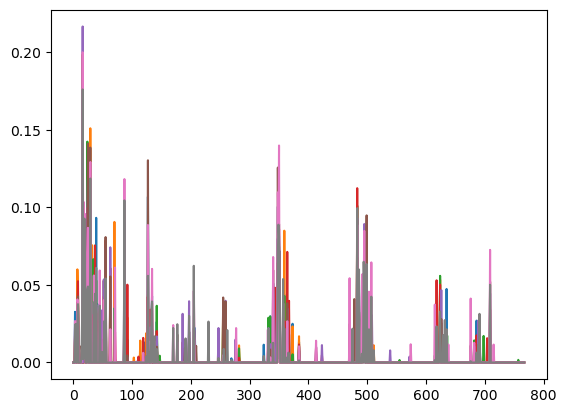

In [45]:
plt.plot(np.array(stim_log).T)
plt.show()

# convert to targets x electrodes x amplitudes. 
stim_log_arr = np.array(stim_log)  # (n_targets, n_patterns)
stim_log_arr = np.reshape(stim_log_arr, (8, 32, -1))



In [50]:
import plotly.graph_objects as go

# make this a function that I can call at other places

proj, _ = np.linalg.qr(np.array([avg_vectors.mean(0), pca.components_[0], pca.components_[1]]).T)
avg_proj = avg_vectors.dot(proj)

def rgba_from_mpl(c, alpha=1.0):
    """Convert a matplotlib color tuple (r,g,b,a) to a plotly rgba string."""
    r, g, b, _ = c
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"

traces = []
for i, angle in enumerate(orientations_deg):
    color = rgba_from_mpl(ori_colors[angle])
    traces.append(go.Scatter3d(
        x=[avg_proj[i, 0]], y=[avg_proj[i, 1]], z=[avg_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"{angle}°",
    ))


    traces.append(go.Scatter3d(
        x=[approx_proj[i, 0]], y=[approx_proj[i, 1]], z=[approx_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, symbol="square", line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"Approx: {angle}°",
    ))

# Origin marker
traces.append(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode="markers",
    marker=dict(size=10, color="black", symbol="x"),
    name="Zero",
))

fig = go.Figure(data=traces)
fig.update_layout(
    title="PCA of Average Visual Response Vectors",
    scene=dict(
        xaxis_title="Proj 1",
        yaxis_title="Proj 2",
        zaxis_title="Proj 3",
    ),
    legend=dict(title="Orientation"),
    width=800, height=650,
)
fig.show()


In [32]:
approx_proj

array([[-0.60739002,  0.01495119, -0.01348062],
       [-0.588449  ,  0.01235031, -0.0128016 ],
       [-0.58652538,  0.01168457, -0.01170064],
       [-0.58040389,  0.01143828, -0.01025347],
       [-0.58955504,  0.01218559, -0.01014874],
       [-0.60102978,  0.01573079, -0.01069302],
       [-0.6211895 ,  0.01702443, -0.01209567],
       [-0.6172278 ,  0.01677447, -0.01386661]])

bin_ms=5.0  offset_bins=1  obs_bins=4
Window: t=[5 … 25] ms post-stim onset

Electrodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Amplitudes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
N_e=32  N_a=6  observed (ch,amp) pairs=192
Trials per (ch,amp): min/median/max = 32 / 32 / 32
Intervals per (ch,amp): min/median/max = 32 / 32 / 32


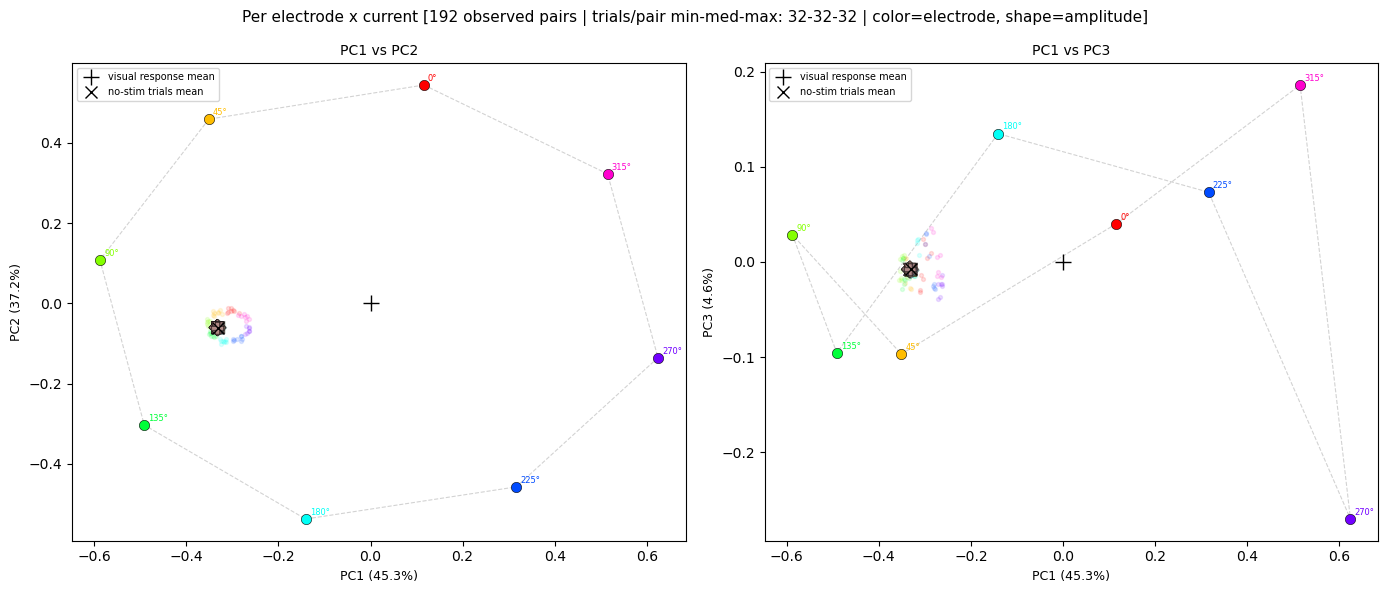

Saved -> /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/no_encoder_1sinterval_sessions/viz/single_pulse_obs_window_ch_amp.png


In [33]:
# ── Observation-window averages projected into PC space ─────────────────────
#
# Mirrors explore_sta.ipynb:
#   OBS_WINDOW_MS — duration of post-stim window to average (ms)
#   OFFSET_MS     — start of window relative to stim onset (ms); skip artifact
#
# PLOT_MODE controls what gets plotted (one panel, 2 PC projections):
#   "ch_amp"    — one point per (electrode × amplitude): N_e × N_a points
#                 color = electrode, shape = amplitude
#   "electrode" — one point per electrode (marginalised over amplitude): N_e points
#                 color = electrode, single marker shape
#   "current"   — one point per amplitude (marginalised over electrode): N_a points
#                 color = amplitude, single marker shape

PLOT_MODE     = "ch_amp"   # "ch_amp" | "electrode" | "current"
OBS_WINDOW_MS = 20.0       # ms of post-stim window to average
OFFSET_MS     = 5.0        # ms after stim onset before window starts

offset_bins = int(OFFSET_MS     / bin_ms)
obs_bins    = int(OBS_WINDOW_MS / bin_ms)
print(f"bin_ms={bin_ms}  offset_bins={offset_bins}  obs_bins={obs_bins}")
print(f"Window: t=[{OFFSET_MS:.0f} … {OFFSET_MS + OBS_WINDOW_MS:.0f}] ms post-stim onset")

# ── Collect per-(ch, amp) vectors with explicit trial membership ────────────
obs_by_condition = defaultdict(lambda: {
    "obs_hz": [],            # interval-level vectors, one per stim interval
    "interval_indices": [],  # global interval indices
    "trial_keys": set(),     # {(session_id, trial_idx_in_session), ...}
})

for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue

    win = spike_bins_arr[i, offset_bins : offset_bins + obs_bins, :n_pca_neurons]
    if win.shape[0] < obs_bins:
        continue   # window shorter than requested — skip

    obs_hz = win.mean(axis=0) / bin_ms   # (n_pca_neurons,) Hz
    ch  = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    key = (ch, amp)

    obs_by_condition[key]["obs_hz"].append(obs_hz)
    obs_by_condition[key]["interval_indices"].append(i)
    obs_by_condition[key]["trial_keys"].add((h["session_id"], h["trial_idx_in_session"]))

if len(obs_by_condition) == 0:
    raise RuntimeError("No stimulated intervals found for the requested observation window.")

all_amps = sorted(set(amp for ch, amp in obs_by_condition))
all_chs  = sorted(set(ch  for ch, amp in obs_by_condition))
N_e, N_a = len(all_chs), len(all_amps)

# Per-condition counts (no equal-trial assumption).
trial_counts_per_pair = {key: len(val["trial_keys"]) for key, val in obs_by_condition.items()}
interval_counts_per_pair = {key: len(val["obs_hz"]) for key, val in obs_by_condition.items()}

trial_count_values = list(trial_counts_per_pair.values())
interval_count_values = list(interval_counts_per_pair.values())

print(f"\nElectrodes: {all_chs}")
print(f"Amplitudes: {all_amps} uA")
print(f"N_e={N_e}  N_a={N_a}  observed (ch,amp) pairs={len(obs_by_condition)}")
print(f"Trials per (ch,amp): min/median/max = {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")
print(f"Intervals per (ch,amp): min/median/max = {min(interval_count_values)} / {int(np.median(interval_count_values))} / {max(interval_count_values)}")

# ── Compute PC coords for each grouping ───────────────────────────────────
avg_ch_amp_pc = {}   # (ch, amp) -> (3,)
for key, val in obs_by_condition.items():
    avg_ch_amp_pc[key] = pca.transform(np.stack(val["obs_hz"]).mean(axis=0)[None])[0]

avg_electrode_pc = {}   # ch -> (3,)
trial_counts_by_electrode = {}
for ch in all_chs:
    vecs = [v for (c, a), val in obs_by_condition.items() if c == ch for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if c == ch:
            trial_keys.update(val["trial_keys"])
    avg_electrode_pc[ch] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_electrode[ch] = len(trial_keys)

avg_current_pc = {}   # amp -> (3,)
trial_counts_by_current = {}
for amp in all_amps:
    vecs = [v for (c, a), val in obs_by_condition.items() if a == amp for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if a == amp:
            trial_keys.update(val["trial_keys"])
    avg_current_pc[amp] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_current[amp] = len(trial_keys)

# ── Marker shapes for amplitude ────────────────────────────────────────────
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
amp_markers  = {amp: _MARKER_POOL[i % len(_MARKER_POOL)] for i, amp in enumerate(all_amps)}

# Amplitude colormap (used in "current" mode)
AMP_CMAP = plt.cm.viridis
amp_norm = plt.Normalize(vmin=min(all_amps),
                         vmax=max(all_amps) if N_a > 1 else max(all_amps) + 1)
amp_col  = {amp: AMP_CMAP(amp_norm(amp)) for amp in all_amps}

# ── Helper: draw orientation ring + reference markers ─────────────────────
def _draw_bg(ax, pc_x, pc_y):
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            "+", ms=12, color="black", zorder=9, label="visual response mean")
    ax.plot(spont_trials_pc[pc_x], spont_trials_pc[pc_y],
            "x", ms=9,  color="black", zorder=9, label="no-stim trials mean")

# ── Title ─────────────────────────────────────────────────────────────────
if PLOT_MODE == "ch_amp":
    mode_title = (
        f"Per electrode x current "
        f"[{len(obs_by_condition)} observed pairs | trials/pair min-med-max: "
        f"{min(trial_count_values)}-{int(np.median(trial_count_values))}-{max(trial_count_values)} | "
        f"color=electrode, shape=amplitude]"
    )
elif PLOT_MODE == "electrode":
    e_counts = list(trial_counts_by_electrode.values())
    mode_title = (
        f"Per electrode (marginalised over amplitude) "
        f"[{N_e} pts | trial-count/electrode min-med-max: "
        f"{min(e_counts)}-{int(np.median(e_counts))}-{max(e_counts)} | color=electrode]"
    )
elif PLOT_MODE == "current":
    c_counts = list(trial_counts_by_current.values())
    mode_title = (
        f"Per current (marginalised over electrode) "
        f"[{N_a} pts | trial-count/current min-med-max: "
        f"{min(c_counts)}-{int(np.median(c_counts))}-{max(c_counts)} | color=amplitude]"
    )
else:
    raise ValueError(f"PLOT_MODE must be 'ch_amp', 'electrode', or 'current'; got {PLOT_MODE!r}")

# ── Figure: 1 row x 2 cols ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"{mode_title}",
    fontsize=11,
)

ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    _draw_bg(ax, pc_x, pc_y)

    if PLOT_MODE == "ch_amp":
        for amp in all_amps:
            xs = [avg_ch_amp_pc[(ch, amp)][pc_x] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ys = [avg_ch_amp_pc[(ch, amp)][pc_y] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            cs = [ch_colors[ch]                   for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ax.scatter(xs, ys, c=cs, s=70, marker=amp_markers[amp],
                       edgecolors="k", lw=0.4, alpha=0.2, zorder=5)

    elif PLOT_MODE == "electrode":
        xs = [avg_electrode_pc[ch][pc_x] for ch in all_chs]
        ys = [avg_electrode_pc[ch][pc_y] for ch in all_chs]
        cs = [ch_colors[ch]              for ch in all_chs]
        ax.scatter(xs, ys, c=cs, s=80, marker="o",
                   edgecolors="k", lw=0.5, alpha=0.4, zorder=5)
        for ch in all_chs:
            pc = avg_electrode_pc[ch]
            ax.annotate(str(ch), xy=(pc[pc_x], pc[pc_y]),
                        xytext=(2, 2), textcoords="offset points", fontsize=6)

    elif PLOT_MODE == "current":
        for amp in all_amps:
            pc = avg_current_pc[amp]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=amp_col[amp], s=160, marker="D",
                       edgecolors="k", lw=0.7, zorder=5)
            ax.annotate(f"{amp} uA", xy=(pc[pc_x], pc[pc_y]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, fontweight="bold")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    # ax.set_xlim(-0.025, 0.01)
    # ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
out = os.path.join(VIZ_DIR, f"single_pulse_obs_window_{PLOT_MODE}.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


Total spikes per pattern (sum over all neurons):
  ch00 1 uA: 2.4 spikes
  ch01 1 uA: 2.4 spikes
  ch02 1 uA: 2.3 spikes
  ch03 1 uA: 2.4 spikes
  ch04 1 uA: 2.4 spikes
  ch05 1 uA: 2.3 spikes
  ch06 1 uA: 2.4 spikes
  ch07 1 uA: 2.4 spikes
  ch08 1 uA: 2.4 spikes
  ch09 1 uA: 2.4 spikes
  ch10 1 uA: 2.4 spikes
  ch11 1 uA: 2.4 spikes
  ch12 1 uA: 2.4 spikes
  ch13 1 uA: 2.4 spikes
  ch14 1 uA: 2.4 spikes
  ch15 1 uA: 2.3 spikes
  ch16 1 uA: 2.4 spikes
  ch17 1 uA: 2.4 spikes
  ch18 1 uA: 2.5 spikes
  ch19 1 uA: 2.5 spikes
  ch20 1 uA: 2.5 spikes
  ch21 1 uA: 2.5 spikes
  ch22 1 uA: 2.5 spikes
  ch23 1 uA: 2.4 spikes
  ch24 1 uA: 2.5 spikes
  ch25 1 uA: 2.6 spikes
  ch26 1 uA: 2.6 spikes
  ch27 1 uA: 2.5 spikes
  ch28 1 uA: 2.7 spikes
  ch29 1 uA: 2.5 spikes
  ch30 1 uA: 2.4 spikes
  ch31 1 uA: 2.4 spikes
  ch00 2 uA: 2.3 spikes
  ch01 2 uA: 2.4 spikes
  ch02 2 uA: 2.4 spikes
  ch03 2 uA: 2.4 spikes
  ch04 2 uA: 2.5 spikes
  ch05 2 uA: 2.4 spikes
  ch06 2 uA: 2.4 spikes
  ch07 2 uA: 2.

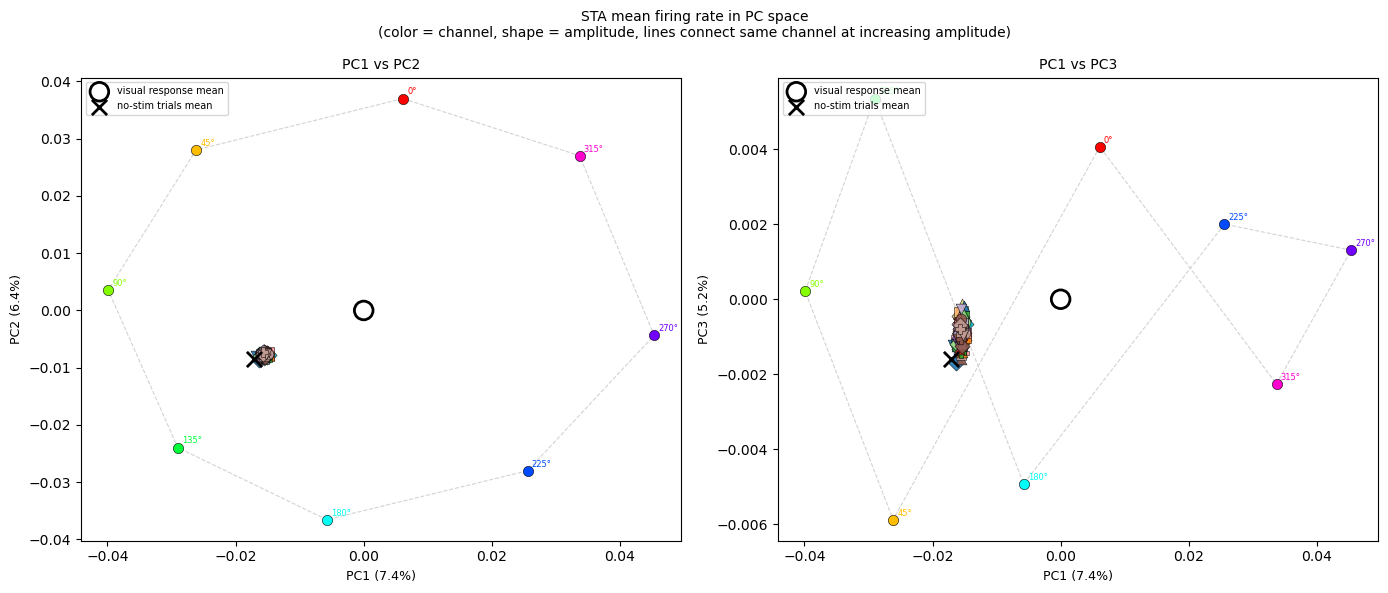

Saved -> /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/no_encoder_1sinterval_sessions/viz/sta_mean_pc_by_channel_amplitude.png


In [50]:
# ── STA mean firing rate projected into PC space ───────────────────────────
#
# For each (ch, amp):
#   mean_hz = average firing rate over the full STA interval → pca.transform()
#   total_spikes = sta_hz.sum(time) * (bin_ms/1000)          → scalar per pattern
#
# Visualization:
#   • one point per (ch, amp)  — color = channel, marker = amplitude
#   • same-channel points connected by a line in ascending amplitude order
#   • visual response mean     — open circle (○)
#   • no-stim trials mean      — cross (×)

all_sta_amps = sorted(set(a for _, a in sta_hz_by_pattern))
all_sta_chs  = sorted(set(c for c, _ in sta_hz_by_pattern))

_STA_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
sta_amp_markers = {a: _STA_MARKER_POOL[i % 10] for i, a in enumerate(all_sta_amps)}
sta_ch_colors   = {c: plt.cm.tab20(i % 20)     for i, c in enumerate(all_sta_chs)}

# Compute mean-Hz STA vector (over time) and project into PC space
sta_mean_pc      = {}   # (ch, amp) -> (3,)
sta_total_spikes = {}   # (ch, amp) -> scalar

for (ch, amp), sta_hz in sta_hz_by_pattern.items():
    # sta_hz: (bpi, n_neurons_sta); trim to PCA neurons
    mean_hz = sta_hz[:, :n_pca_neurons].mean(axis=0)           # (n_pca_neurons,) Hz
    sta_mean_pc[(ch, amp)]      = pca.transform(mean_hz[None, :])[0]
    # total spikes: sum over time bins, convert Hz to spike counts
    sta_total_spikes[(ch, amp)] = float((sta_hz.sum(axis=0) * (bin_ms / 1000.0)).sum())

print("Total spikes per pattern (sum over all neurons):")
for (ch, amp) in sorted(sta_total_spikes, key=lambda k: (k[1], k[0])):
    print(f"  ch{ch:02d} {amp:g} uA: {sta_total_spikes[(ch, amp)]:.1f} spikes")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "STA mean firing rate in PC space\n"
    "(color = channel, shape = amplitude, lines connect same channel at increasing amplitude)",
    fontsize=10,
)

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    # Orientation ring background
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])

    # Visual response mean — open circle
    ax.scatter(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
               s=180, marker="o", facecolors="none", edgecolors="black", lw=2.0,
               zorder=10, label="visual response mean")

    # No-stim trials mean — cross
    ax.scatter(spont_trials_pc[pc_x], spont_trials_pc[pc_y],
               s=120, marker="x", color="black", lw=2.0,
               zorder=10, label="no-stim trials mean")

    # One line + points per channel (ascending amplitude order)
    for ch in all_sta_chs:
        amps_for_ch = sorted(a for (c, a) in sta_mean_pc if c == ch)
        if not amps_for_ch:
            continue
        xs = [sta_mean_pc[(ch, a)][pc_x] for a in amps_for_ch]
        ys = [sta_mean_pc[(ch, a)][pc_y] for a in amps_for_ch]
        ax.plot(xs, ys, color=sta_ch_colors[ch], lw=1.0, alpha=0.45, zorder=4)
        for a in amps_for_ch:
            pc = sta_mean_pc[(ch, a)]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=sta_ch_colors[ch], s=60, marker=sta_amp_markers[a],
                       edgecolors="k", lw=0.4, alpha=0.9, zorder=5)

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
out = os.path.join(VIZ_DIR, "sta_mean_pc_by_channel_amplitude.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

In [ ]:
for current in all_amps:
    print(f"Current {current} uA:")
    for ch in all_chs:
        key = (ch, current)
        if key in avg_ch_amp_pc:
            # already have mean PC coords for this (ch, amp) pair
            pc = avg_ch_amp_pc[key]
            print(f"  Electrode {ch}: mean PC coords = {pc.round(4)}")
        
            # calculate variance across intervals for this (ch, amp) pair
            obs_hz_list = obs_by_condition[key]["obs_hz"]
            if len(obs_hz_list) > 1:
                obs_hz_array = np.stack(obs_hz_list)  # shape: (n_intervals, n_pca_neurons)
                obs_pc_array = pca.transform(obs_hz_array)  # shape: (n_intervals, 3)
                pc_variance = obs_pc_array.var(axis=0)  # variance along each PC dimension
                print(f"    Variance across intervals: {pc_variance.round(6)}")
            else:
                print(f"    Only one interval for this (ch, amp) pair; cannot compute variance.")
        else:
            print(f"  Electrode {ch}: no data for this current level.")



Current 1.0 uA:
  Electrode 0: mean PC coords = [-0.0187 -0.009  -0.0003]
    Variance across intervals: [1.e-06 3.e-06 2.e-06]
  Electrode 1: mean PC coords = [-0.0191 -0.0092 -0.0006]
    Variance across intervals: [1.e-06 2.e-06 1.e-06]
  Electrode 2: mean PC coords = [-0.0188 -0.0092 -0.0004]
    Variance across intervals: [1.e-06 1.e-06 1.e-06]
  Electrode 3: mean PC coords = [-0.0186 -0.0092 -0.001 ]
    Variance across intervals: [1.e-06 1.e-06 2.e-06]
  Electrode 4: mean PC coords = [-0.0188 -0.0094 -0.0008]
    Variance across intervals: [2.e-06 1.e-06 1.e-06]
  Electrode 5: mean PC coords = [-0.019  -0.0096 -0.0006]
    Variance across intervals: [0.e+00 0.e+00 1.e-06]
  Electrode 6: mean PC coords = [-0.0186 -0.009  -0.0009]
    Variance across intervals: [1.e-06 1.e-06 2.e-06]
  Electrode 7: mean PC coords = [-0.0187 -0.0093 -0.0005]
    Variance across intervals: [2.e-06 0.e+00 1.e-06]
  Electrode 8: mean PC coords = [-0.0189 -0.0093 -0.0009]
    Variance across intervals:

bin_ms=5.0  offset_bins=1  obs_bins=4
Window: t=[5 … 25] ms post-stim onset

Electrodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Amplitudes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
N_e=32  N_a=6  observed (ch,amp) pairs=192
Trials per (ch,amp): min/median/max = 32 / 32 / 32
Intervals per (ch,amp): min/median/max = 32 / 32 / 32


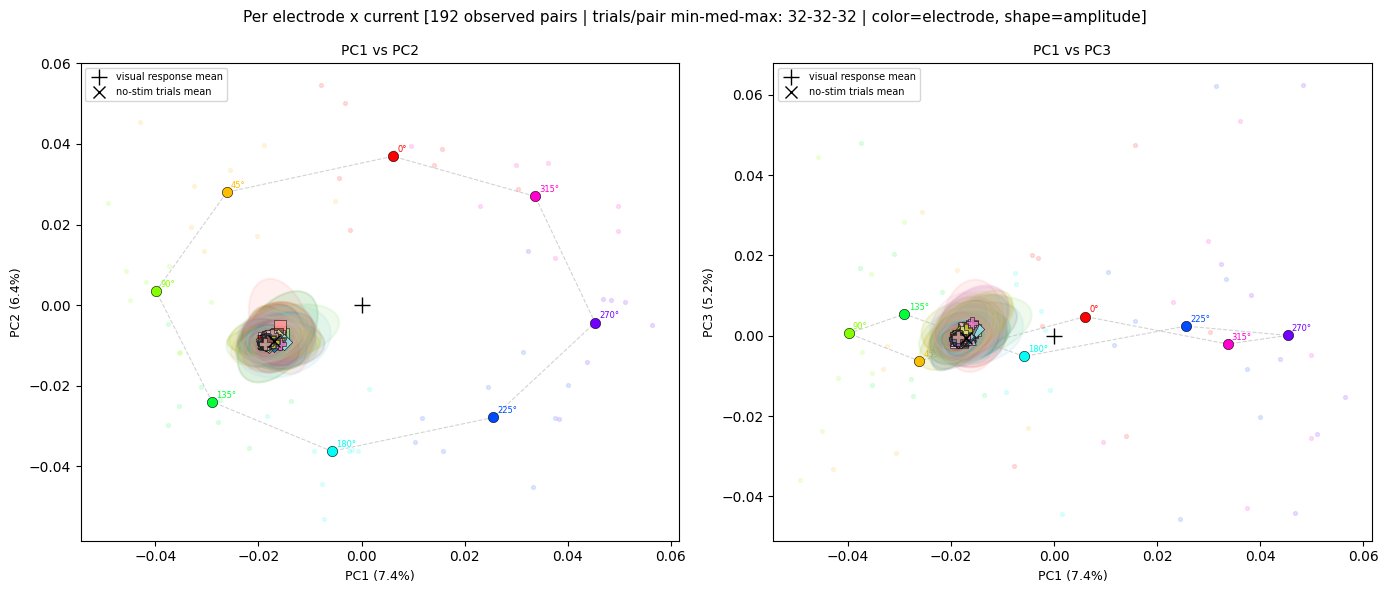

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/single_pulse_obs_window_ch_amp.png


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from collections import defaultdict

# ── Observation-window averages projected into PC space ─────────────────────
#
# Mirrors explore_sta.ipynb:
#   OBS_WINDOW_MS — duration of post-stim window to average (ms)
#   OFFSET_MS     — start of window relative to stim onset (ms); skip artifact
#
# PLOT_MODE controls what gets plotted (one panel, 2 PC projections):
#   "ch_amp"    — one point per (electrode × amplitude): N_e × N_a points
#                 color = electrode, shape = amplitude
#   "electrode" — one point per electrode (marginalised over amplitude): N_e points
#                 color = electrode, single marker shape
#   "current"   — one point per amplitude (marginalised over electrode): N_a points
#                 color = amplitude, single marker shape

PLOT_MODE     = "ch_amp"   # "ch_amp" | "electrode" | "current"
OBS_WINDOW_MS = 20.0       # ms of post-stim window to average
OFFSET_MS     = 5.0        # ms after stim onset before window starts

offset_bins = int(OFFSET_MS     / bin_ms)
obs_bins    = int(OBS_WINDOW_MS / bin_ms)
print(f"bin_ms={bin_ms}  offset_bins={offset_bins}  obs_bins={obs_bins}")
print(f"Window: t=[{OFFSET_MS:.0f} … {OFFSET_MS + OBS_WINDOW_MS:.0f}] ms post-stim onset")

# ── Collect per-(ch, amp) vectors with explicit trial membership ────────────
obs_by_condition = defaultdict(lambda: {
    "obs_hz": [],            # interval-level vectors, one per stim interval
    "interval_indices": [],  # global interval indices
    "trial_keys": set(),     # {(session_id, trial_idx_in_session), ...}
})

for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue

    win = spike_bins_arr[i, offset_bins : offset_bins + obs_bins, :n_pca_neurons]
    if win.shape[0] < obs_bins:
        continue   # window shorter than requested — skip

    obs_hz = win.mean(axis=0) / bin_ms   # (n_pca_neurons,) Hz
    ch  = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    key = (ch, amp)

    obs_by_condition[key]["obs_hz"].append(obs_hz)
    obs_by_condition[key]["interval_indices"].append(i)
    obs_by_condition[key]["trial_keys"].add((h["session_id"], h["trial_idx_in_session"]))

if len(obs_by_condition) == 0:
    raise RuntimeError("No stimulated intervals found for the requested observation window.")

all_amps = sorted(set(amp for ch, amp in obs_by_condition))
all_chs  = sorted(set(ch  for ch, amp in obs_by_condition))
N_e, N_a = len(all_chs), len(all_amps)

# Per-condition counts (no equal-trial assumption).
trial_counts_per_pair = {key: len(val["trial_keys"]) for key, val in obs_by_condition.items()}
interval_counts_per_pair = {key: len(val["obs_hz"]) for key, val in obs_by_condition.items()}

trial_count_values = list(trial_counts_per_pair.values())
interval_count_values = list(interval_counts_per_pair.values())

print(f"\nElectrodes: {all_chs}")
print(f"Amplitudes: {all_amps} uA")
print(f"N_e={N_e}  N_a={N_a}  observed (ch,amp) pairs={len(obs_by_condition)}")
print(f"Trials per (ch,amp): min/median/max = {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")
print(f"Intervals per (ch,amp): min/median/max = {min(interval_count_values)} / {int(np.median(interval_count_values))} / {max(interval_count_values)}")

# ── Compute PC coords & Covariance for each grouping ──────────────────────
avg_ch_amp_pc = {}   # (ch, amp) -> (3,)
cov_ch_amp_pc = {}   # (ch, amp) -> (3, 3) covariance matrix
for key, val in obs_by_condition.items():
    obs_hz_array = np.stack(val["obs_hz"])
    obs_pc_array = pca.transform(obs_hz_array)
    avg_ch_amp_pc[key] = obs_pc_array.mean(axis=0)
    
    # Need >1 observation to calculate covariance
    if obs_pc_array.shape[0] > 1:
        cov_ch_amp_pc[key] = np.cov(obs_pc_array, rowvar=False)
    else:
        cov_ch_amp_pc[key] = None

avg_electrode_pc = {}   # ch -> (3,)
trial_counts_by_electrode = {}
for ch in all_chs:
    vecs = [v for (c, a), val in obs_by_condition.items() if c == ch for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if c == ch:
            trial_keys.update(val["trial_keys"])
    avg_electrode_pc[ch] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_electrode[ch] = len(trial_keys)

avg_current_pc = {}   # amp -> (3,)
trial_counts_by_current = {}
for amp in all_amps:
    vecs = [v for (c, a), val in obs_by_condition.items() if a == amp for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if a == amp:
            trial_keys.update(val["trial_keys"])
    avg_current_pc[amp] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_current[amp] = len(trial_keys)

# ── Marker shapes for amplitude ────────────────────────────────────────────
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
amp_markers  = {amp: _MARKER_POOL[i % len(_MARKER_POOL)] for i, amp in enumerate(all_amps)}

# Amplitude colormap (used in "current" mode)
AMP_CMAP = plt.cm.viridis
amp_norm = plt.Normalize(vmin=min(all_amps),
                         vmax=max(all_amps) if N_a > 1 else max(all_amps) + 1)
amp_col  = {amp: AMP_CMAP(amp_norm(amp)) for amp in all_amps}

# ── Helper: draw orientation ring + reference markers ─────────────────────
def _draw_bg(ax, pc_x, pc_y):
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            "+", ms=12, color="black", zorder=9, label="visual response mean")
    ax.plot(spont_trials_pc[pc_x], spont_trials_pc[pc_y],
            "x", ms=9,  color="black", zorder=9, label="no-stim trials mean")

# ── Title ─────────────────────────────────────────────────────────────────
if PLOT_MODE == "ch_amp":
    mode_title = (
        f"Per electrode x current "
        f"[{len(obs_by_condition)} observed pairs | trials/pair min-med-max: "
        f"{min(trial_count_values)}-{int(np.median(trial_count_values))}-{max(trial_count_values)} | "
        f"color=electrode, shape=amplitude]"
    )
elif PLOT_MODE == "electrode":
    e_counts = list(trial_counts_by_electrode.values())
    mode_title = (
        f"Per electrode (marginalised over amplitude) "
        f"[{N_e} pts | trial-count/electrode min-med-max: "
        f"{min(e_counts)}-{int(np.median(e_counts))}-{max(e_counts)} | color=electrode]"
    )
elif PLOT_MODE == "current":
    c_counts = list(trial_counts_by_current.values())
    mode_title = (
        f"Per current (marginalised over electrode) "
        f"[{N_a} pts | trial-count/current min-med-max: "
        f"{min(c_counts)}-{int(np.median(c_counts))}-{max(c_counts)} | color=amplitude]"
    )
else:
    raise ValueError(f"PLOT_MODE must be 'ch_amp', 'electrode', or 'current'; got {PLOT_MODE!r}")

# ── Figure: 1 row x 2 cols ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"{mode_title}",
    fontsize=11,
)

ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    _draw_bg(ax, pc_x, pc_y)

    if PLOT_MODE == "ch_amp":
        for key in avg_ch_amp_pc:
            ch, amp = key
            mean_pc = avg_ch_amp_pc[key]
            cov_pc  = cov_ch_amp_pc[key]
            
            # Scatter the mean marker
            ax.scatter(mean_pc[pc_x], mean_pc[pc_y],
                       c=[ch_colors[ch]], s=70, marker=amp_markers[amp],
                       edgecolors="k", lw=0.4, alpha=0.9, zorder=6)
            
            # Draw the covariance ellipse (if we had >1 observation)
            if cov_pc is not None:
                # Slice out the 2x2 covariance for the current 2D projection
                cov2d = np.array([[cov_pc[pc_x, pc_x], cov_pc[pc_x, pc_y]],
                                  [cov_pc[pc_y, pc_x], cov_pc[pc_y, pc_y]]])
                
                # Compute eigenvectors/values to orient the ellipse
                vals, vecs = np.linalg.eigh(cov2d)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                
                # Get rotation angle in degrees
                theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
                
                # 4 * std_dev (1 std dev radius = sqrt(eigenvalue))
                width, height = 4 * np.sqrt(np.maximum(vals, 0))
                
                ell = Ellipse(xy=(mean_pc[pc_x], mean_pc[pc_y]),
                              width=width, height=height, angle=theta,
                              facecolor=ch_colors[ch], alpha=0.15,
                              edgecolor=ch_colors[ch], lw=1.5, zorder=5)
                ax.add_patch(ell)

    elif PLOT_MODE == "electrode":
        xs = [avg_electrode_pc[ch][pc_x] for ch in all_chs]
        ys = [avg_electrode_pc[ch][pc_y] for ch in all_chs]
        cs = [ch_colors[ch]              for ch in all_chs]
        ax.scatter(xs, ys, c=cs, s=80, marker="o",
                   edgecolors="k", lw=0.5, alpha=0.4, zorder=5)
        for ch in all_chs:
            pc = avg_electrode_pc[ch]
            ax.annotate(str(ch), xy=(pc[pc_x], pc[pc_y]),
                        xytext=(2, 2), textcoords="offset points", fontsize=6)

    elif PLOT_MODE == "current":
        for amp in all_amps:
            pc = avg_current_pc[amp]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=amp_col[amp], s=160, marker="D",
                       edgecolors="k", lw=0.7, zorder=5)
            ax.annotate(f"{amp} uA", xy=(pc[pc_x], pc[pc_y]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, fontweight="bold")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    # ax.set_xlim(-0.025, 0.01)
    # ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
# Assuming VIZ_DIR is defined higher up in your notebook/script
out = os.path.join(VIZ_DIR, f"single_pulse_obs_window_{PLOT_MODE}.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

In [30]:
# ── Save Individual Figures for Each (Ch, Amp) Combination ─────────────────

# Make sure the directory exists just in case
ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

# Loop through every pre-calculated channel & amplitude pair
for key in avg_ch_amp_pc:
    ch, amp = key
    mean_pc = avg_ch_amp_pc[key]
    cov_pc  = cov_ch_amp_pc[key]
    
    # Create a fresh figure for this pair
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Title specific to this pair and window
    fig.suptitle(f"Stimulation Response: Electrode {ch} | {amp} uA\n"
                 f"Window: {OFFSET_MS:.0f} to {OFFSET_MS + OBS_WINDOW_MS:.0f} ms post-stim", 
                 fontsize=13, fontweight='bold')

    for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
        # 1. Draw the background context (visual ring, spontaneous means)
        _draw_bg(ax, pc_x, pc_y)
        
        # 2. Scatter the mean marker for THIS condition
        ax.scatter(mean_pc[pc_x], mean_pc[pc_y],
                   c=[ch_colors[ch]], s=150, marker=amp_markers[amp],
                   edgecolors="k", lw=1.2, alpha=0.95, zorder=10,
                   label=f"Stim Mean (Ch {ch}, {amp}uA)")
        
        # 3. Draw the covariance ellipse if we have enough trials
        if cov_pc is not None:
            cov2d = np.array([[cov_pc[pc_x, pc_x], cov_pc[pc_x, pc_y]],
                              [cov_pc[pc_y, pc_x], cov_pc[pc_y, pc_y]]])
            
            vals, vecs = np.linalg.eigh(cov2d)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            
            theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 4 * np.sqrt(np.maximum(vals, 0))
            
            # Bumped up the alpha slightly since it's the only ellipse on the plot now
            ell = Ellipse(xy=(mean_pc[pc_x], mean_pc[pc_y]),
                          width=width, height=height, angle=theta,
                          facecolor=ch_colors[ch], alpha=0.3, 
                          edgecolor=ch_colors[ch], lw=1.5, zorder=5,
                          label="2 Std Dev Covariance")
            ax.add_patch(ell)

        # 4. Formatting
        ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=10)
        ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=10)
        ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=11)
        
        # You might want to uncomment these to lock the axes bounds so 
        # the background doesn't jump around when flipping through images
        ax.set_xlim(-0.025, 0.015) 
        ax.set_ylim(-0.025, 0.015)
        
        ax.legend(fontsize=8, loc="upper left")

    plt.tight_layout()
    
    # Construct a clean filename
    filename = f"sta_ch{ch}_amp{amp}_{OFFSET_MS:.0f}to{OFFSET_MS+OBS_WINDOW_MS:.0f}ms.png"
    out = os.path.join(VIZ_DIR, filename)
    
    # Save and explicitly close the figure so Jupyter doesn't crash from memory overload
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig) 
    print(f"Saved -> {out}")

print("\nFinished saving all individual STAs!")

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch0_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch1_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch2_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch3_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch4_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch5_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outp

In [17]:
# ── No-Stim Baseline: Observation Window ──────────────────────────────────────
#
# Extract no-stim intervals during the observation window and project to PC space.
# This shows where spontaneous activity settles during the same window used
# for evoked responses in the previous analysis.

OBS_WINDOW_MS_NOSTIM = 0.0        # ms of observation window
OFFSET_MS_NOSTIM     = 100.0       # ms after interval start (skip early transients)

offset_bins_nostim = int(OFFSET_MS_NOSTIM     / bin_ms)
obs_bins_nostim    = int(OBS_WINDOW_MS_NOSTIM / bin_ms)
print(f"Window: t=[{OFFSET_MS_NOSTIM:.0f}–{OFFSET_MS_NOSTIM + OBS_WINDOW_MS_NOSTIM:.0f}] ms post-interval start")

# Collect no-stim observation windows
no_stim_obs_vecs = []  # list of (n_pca_neurons,) Hz vectors
for i in no_stim_idx:
    win = spike_bins_arr[i, offset_bins_nostim : offset_bins_nostim + obs_bins_nostim, :n_pca_neurons]
    if win.shape[0] < obs_bins_nostim:
        continue
    obs_hz = win.mean(axis=0) / bin_ms
    no_stim_obs_vecs.append(obs_hz)

no_stim_obs_vecs = np.array(no_stim_obs_vecs)
no_stim_obs_pc = pca.transform(no_stim_obs_vecs)  # (n_no_stim, 3)
no_stim_obs_mean_pc = no_stim_obs_pc.mean(axis=0)

print(f"No-stim observation windows collected: {len(no_stim_obs_vecs)}")
print(f"Mean position in PC space: {no_stim_obs_mean_pc}")

# Figure: 2-panel view
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"No-Stim Baseline: Observation Window ({OFFSET_MS_NOSTIM:.0f}–{OFFSET_MS_NOSTIM + OBS_WINDOW_MS_NOSTIM:.0f} ms post-interval start)",
    fontsize=11,
)

baseline_pc = no_stim_ever_pc if "no_stim_ever_pc" in globals() else spont_trials_pc

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    # Background: visual orientation ring
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])

    # No-stim observation window projections
    ax.scatter(no_stim_obs_pc[:, pc_x], no_stim_obs_pc[:, pc_y],
               color="red", s=35, alpha=0.3, edgecolors="none", zorder=4,
               label=f"no-stim obs window (n={len(no_stim_obs_vecs)})")

    # Mean of no-stim observations
    ax.scatter(no_stim_obs_mean_pc[pc_x], no_stim_obs_mean_pc[pc_y],
               color="red", s=120, marker="x", zorder=7,
               label="no-stim obs mean")

    # Visual origin
    ax.scatter(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
               color="black", s=60, marker="o", edgecolors="k", lw=0.4, zorder=8,
               label="visual origin")

    # Spontaneous baseline
    ax.scatter(baseline_pc[pc_x], baseline_pc[pc_y],
               color="black", s=100, marker="x", zorder=9,
               label="spont baseline (full interval)")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    ax.set_xlim(-0.025, 0.01)
    ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
out = os.path.join(VIZ_DIR, f"no_stim_obs_window.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


Window: t=[100–100] ms post-interval start


/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_87960/2720782467.py:20: RuntimeWarning: Mean of empty slice
  obs_hz = win.mean(axis=0) / bin_ms
/opt/homebrew/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values